# Alpha-Driven RFQ Simulator

This notebook demonstrates the RFQ simulator for alpha-driven liquidity provision in corporate bond markets.

**Core question:** Does spread income from patient RFQ-based trading exceed the alpha P&L sacrificed by slower convergence to the target position?

## Contents
1. Setup and Configuration
2. Single Path Demo
3. Win-Rate Calibration Validation
4. LP vs Baseline Comparison
5. Sensitivity Analysis
6. Monte Carlo Analysis

In [1]:
# Setup path for local development
import sys
sys.path.insert(0, '../src')

# Core imports
import numpy as np
import matplotlib.pyplot as plt

# Simulator imports
from rfq_simulator import (
    SimConfig,
    run_simulation,
    run_baseline,
    compare_strategies,
    run_batch,
    run_scenario_sweep,
)
from rfq_simulator.output import (
    plot_simulation_results,
    plot_pnl_decomposition,
    create_rfq_dataframe,
    generate_summary_report,
)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Setup and Configuration

Create a configuration with default parameters from the spec.

In [2]:
# Create configuration with default parameters
cfg = SimConfig(
    # Simulation control
    T_days=60,
    dt_minutes=5.0,
    seed=42,
    
    # Price process
    p0=100.0,
    sigma_daily_bps=50.0,  # IG volatility
    kappa_daily=0.02,
    
    # Alpha signal
    IC=0.10,  # Moderate IC
    alpha_horizon_days=10.0,
    signal_refresh_hours=24.0,
    
    # RFQ arrivals
    rfq_rate_per_day=15.0,
    n_dealers_mean=4.0,
    
    # Position limits
    q_max=20,
    gamma=1.0,
)

cfg.validate()
print("Configuration validated successfully")
print(f"Total simulation: {cfg.T_days} days, {cfg.n_steps} price steps")
print(f"Expected RFQs: ~{cfg.rfq_rate_per_day * cfg.T_days:.0f}")

Configuration validated successfully
Total simulation: 60 days, 5760 price steps
Expected RFQs: ~900


## 2. Single Path Demo

Run a single simulation path to visualize the strategy behavior.

In [3]:
# Run single simulation
result = run_simulation(cfg, verbose=True)

Generating world processes...
  Price path: 5761 steps
  RFQ events: 1002
  Stress regime: 26.7% of days
  Street lean range: [-8.67, 10.60] bps
Processing RFQ events...
  New alpha signal: α=0.32, α*=0.60
Simulation complete:
  Total P&L: $-444,239.29
  Alpha P&L: $130,266.80
  Spread P&L: $-574,468.59
  Fill rate: 53.7%
  Final inventory: 6.0 lots


In [4]:
# Display summary
print("\n" + "="*60)
summary = result.summary()
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:,.2f}")
    else:
        print(f"{k}: {v}")


total_pnl: -444,239.29
alpha_pnl: 130,266.80
spread_pnl: -574,468.59
carry_pnl: -37.50
aggress_cost: 0.00
n_rfqs: 1002
n_fills: 537
fill_rate: 0.54
avg_spread_bps: -10.70
final_inventory: 6.00
sharpe: -3.28
max_drawdown: 444,239.29


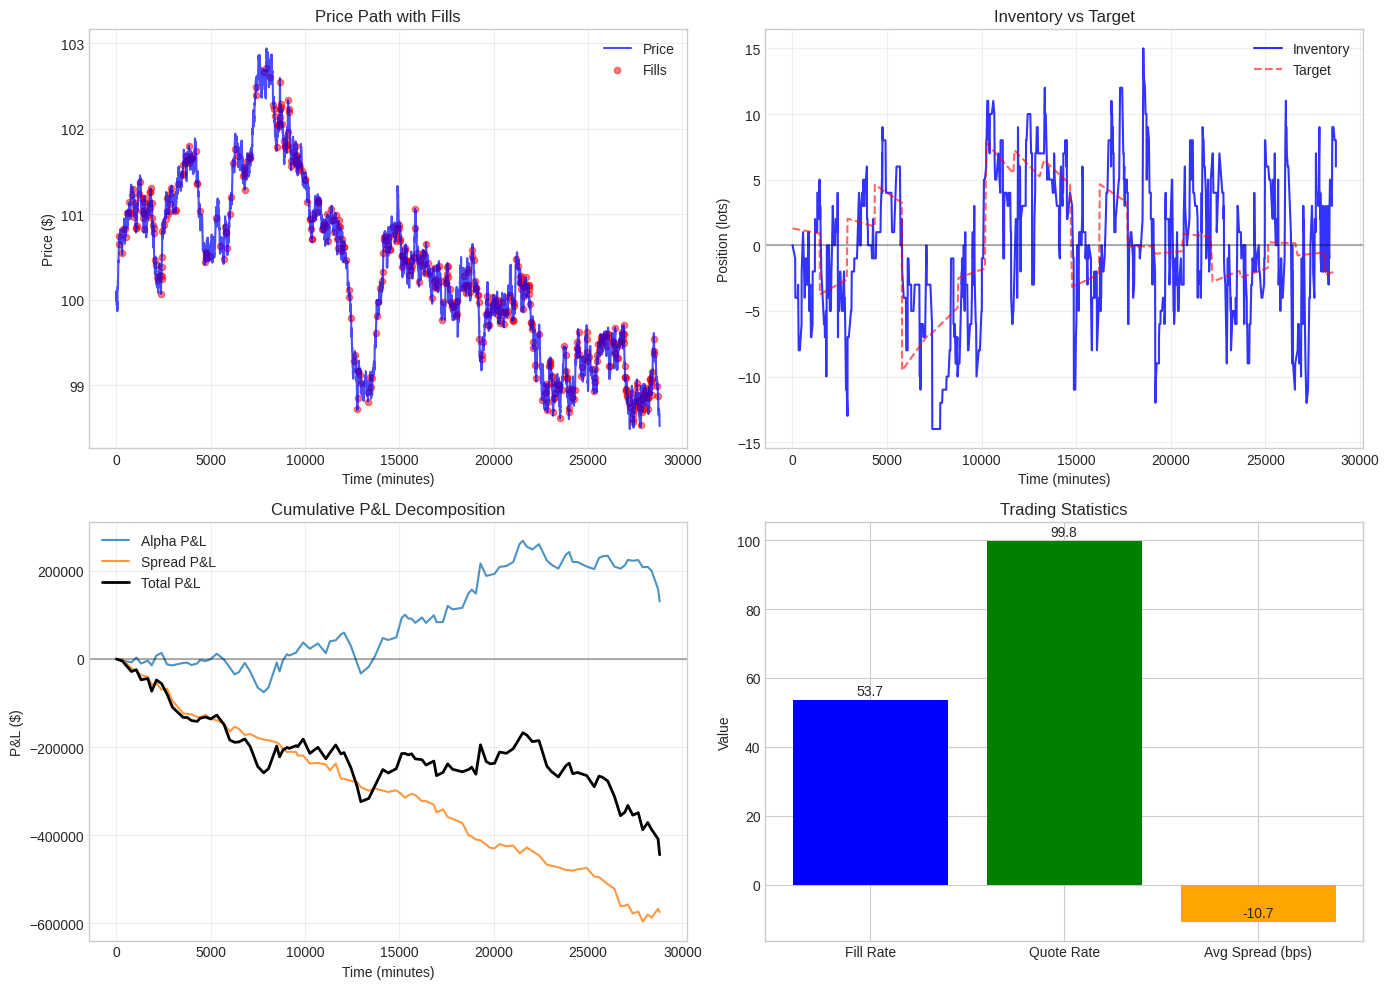

In [5]:
# Visualize results
fig = plot_simulation_results(result)

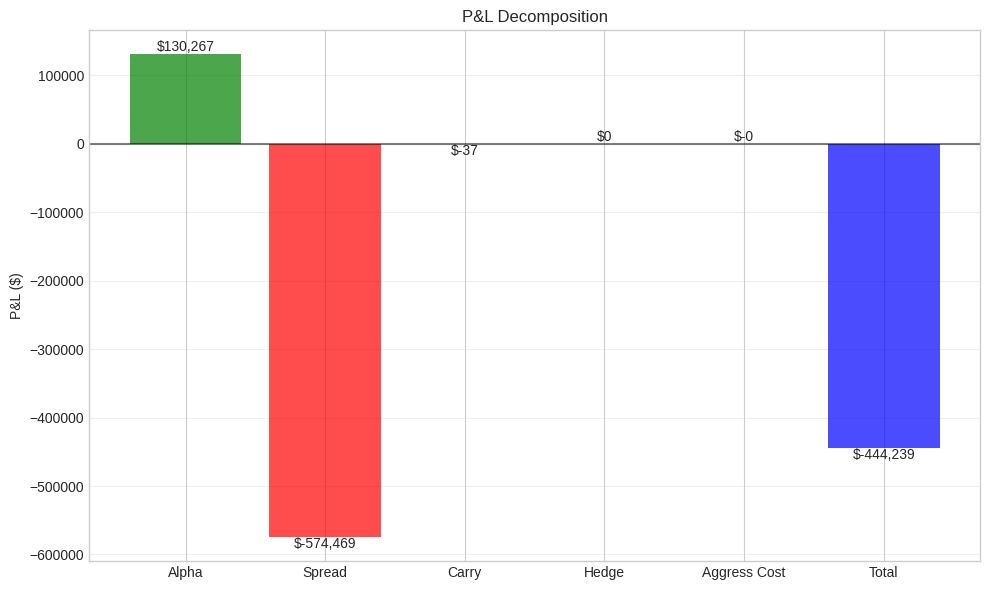

In [6]:
# P&L decomposition
fig = plot_pnl_decomposition(result)

In [7]:
# Create DataFrame for detailed analysis
df = create_rfq_dataframe(result)
if df is not None:
    print(f"RFQ log: {len(df)} events")
    display(df.head(10))
    
    # Fill statistics
    print(f"\nFill rate: {df['filled'].mean():.1%}")
    print(f"Avg spread (filled): {df[df['filled']]['spread_pnl'].mean():.2f}")

RFQ log: 1002 events


,time,day,is_client_buy,size,n_dealers,toxicity,p_true,theo,theo_error,markup_bps,win_prob_est,declined,filled,spread_pnl,adverse_move,q_before,q_after,q_target,alpha_remaining,regime
0,8.710246,0,False,1,3,0.084408,100.105346,100.078198,-0.027148,7.5,0.634380,False,False,0.000000,0.000000,0.0,0.0,1.282334,0.320584,CALM
1,147.854928,0,True,1,2,0.043885,100.652205,100.546796,-0.105409,8.2,0.651686,False,True,-234.087746,0.000235,0.0,-1.0,1.245162,0.311290,CALM
2,155.564512,0,True,3,1,0.330356,100.743306,100.695417,-0.047889,10.5,0.708182,False,True,1713.332625,0.011633,-1.0,-4.0,1.243102,0.310775,CALM
3,212.232513,0,True,2,4,0.118184,100.724003,101.057688,0.333686,7.6,0.666137,False,False,0.000000,0.000000,-4.0,-4.0,1.227963,0.306991,CALM
4,235.865724,0,True,2,2,0.052250,100.749842,100.800205,0.050363,9.1,0.689055,False,False,0.000000,0.000000,-4.0,-4.0,1.221649,0.305412,CALM
5,237.694086,0,True,2,3,0.158090,100.749842,100.905040,0.155199,8.4,0.674740,False,False,0.000000,0.000000,-4.0,-4.0,1.221161,0.305290,CALM
6,243.037849,0,True,3,4,0.179262,100.751632,100.943263,0.191631,8.2,0.684025,False,False,0.000000,0.000000,-4.0,-4.0,1.219733,0.304933,CALM
7,273.592863,0,True,1,5,0.040635,100.671585,100.832604,0.161019,6.1,0.590355,False,False,0.000000,0.000000,-4.0,-4.0,1.211570,0.302893,CALM
8,282.864989,0,True,1,5,0.217728,100.590001,100.897898,0.307897,6.1,0.590355,False,False,0.000000,0.000000,-4.0,-4.0,1.209093,0.302273,CALM
9,302.314644,0,False,1,1,0.329290,100.549979,100.738431,0.188452,9.0,0.658675,False,True,-984.517787,-0.005532,-4.0,-3.0,1.203897,0.300974,CALM



Fill rate: 53.6%
Avg spread (filled): -1069.77


## 3. Win-Rate Calibration Validation

Verify that estimated win probabilities match realized fill rates.

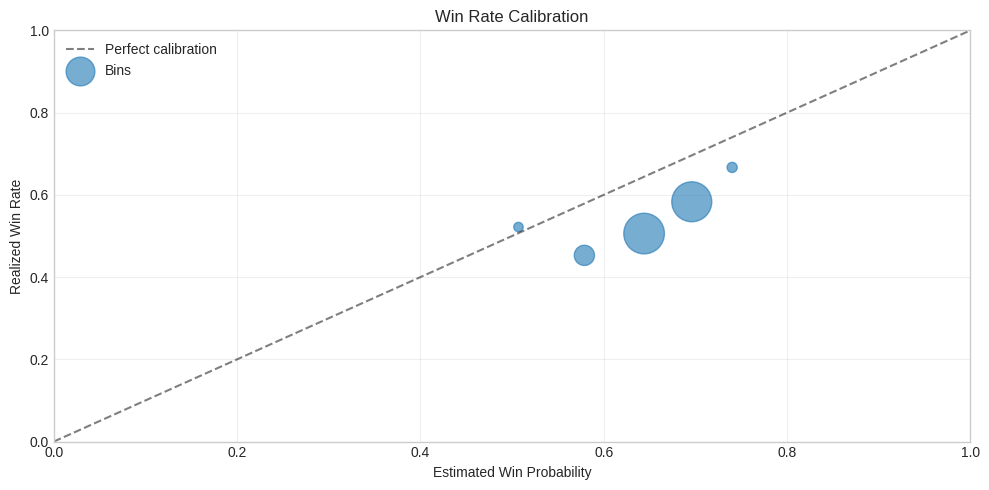

In [8]:
from rfq_simulator.output.diagnostics import plot_win_rate_calibration

fig = plot_win_rate_calibration(result, n_bins=15)

## 4. LP vs Baseline Comparison

Compare the LP (liquidity provider) strategy against the naive aggressor baseline.

In [9]:
# Run baseline on same price path
baseline = run_baseline(
    prices=result.prices,
    regime_path=result.regime_path,
    cfg=cfg,
    seed=cfg.seed,
    verbose=True,
)

Running baseline strategy...
  Day 0: New signal α=0.39
Baseline complete:
  Total P&L: $-275,160.69
  Alpha P&L: $-135,269.64
  Aggress cost: $139,868.75
  Total trades: 5761


In [10]:
# Compare strategies
comparison = compare_strategies(result, baseline)

print("\nSTRATEGY COMPARISON")
print("="*50)
for k, v in comparison.items():
    print(f"{k}: {v:,.2f}" if isinstance(v, float) else f"{k}: {v}")

print("\n" + "="*50)
if comparison['spread_minus_alpha_loss'] > 0:
    print(">>> LP STRATEGY WINS <<<")
    print(f"Net benefit: ${comparison['spread_minus_alpha_loss']:,.2f}")
else:
    print(">>> BASELINE WINS <<<")
    print(f"LP shortfall: ${-comparison['spread_minus_alpha_loss']:,.2f}")


STRATEGY COMPARISON
lp_total_pnl: -444,239.29
baseline_total_pnl: -275,160.69
pnl_difference: -169,078.60
lp_alpha_pnl: 130,266.80
baseline_alpha_pnl: -135,269.64
alpha_sacrifice: -265,536.45
lp_spread_pnl: -574,468.59
baseline_spread_pnl: 0.00
lp_aggress_cost: 0.00
baseline_aggress_cost: 139,868.75
lp_fill_rate: 0.54
lp_avg_spread_bps: -10.70
baseline_avg_gap: 0.02
lp_final_inventory: 6.00
spread_minus_alpha_loss: -308,932.15

>>> BASELINE WINS <<<
LP shortfall: $308,932.15


In [11]:
# Generate full report
report = generate_summary_report(result, baseline)
print(report)

RFQ SIMULATOR SUMMARY REPORT

CONFIGURATION:
  Simulation days: 60
  Daily vol (bps): 50.0
  IC: 0.1
  RFQs per day: 15.0
  Position limit: 20 lots

P&L DECOMPOSITION:
  Alpha P&L:    $  130,266.80
  Spread P&L:   $ -574,468.59
  Carry P&L:    $      -37.50
  Hedge P&L:    $        0.00
  Aggress Cost: $        0.00
  ---------------------
  TOTAL P&L:    $ -444,239.29

TRADING STATISTICS:
  RFQs seen: 1002
  RFQs quoted: 1000
  RFQs filled: 537
  Quote rate: 99.8%
  Fill rate: 53.7%
  Avg spread (bps): -10.70
  Total volume: 1462.0 lots
  Final inventory: 6.0 lots

RISK METRICS:
  Sharpe ratio: -3.28
  Max drawdown: $444,239.29

BASELINE COMPARISON:
  Baseline P&L: $ -275,160.69
  LP P&L:       $ -444,239.29
  Difference:   $ -169,078.60

  Alpha sacrifice: $ -265,536.45
  Spread earned:   $ -574,468.59
  Net benefit:     $ -308,932.15

  >> BASELINE OUTPERFORMS LP STRATEGY <<



## 5. Sensitivity Analysis

Sweep key parameters to understand strategy behavior.

In [12]:
# Sweep IC (information coefficient)
ic_sweep = run_scenario_sweep(
    base_cfg=cfg,
    param_name='IC',
    param_values=[0.03, 0.05, 0.08, 0.10, 0.12, 0.15],
    n_paths_per_scenario=20,
    verbose=True,
)


Scenario 1/6: IC=0.03
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-1,149,960.05
  Std P&L: $618,279.60
  Sharpe: -1.86
  vs Baseline: $-957,803.93
  Outperformance rate: 0.0%

Scenario 2/6: IC=0.05
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-1,164,233.95
  Std P&L: $514,504.65
  Sharpe: -2.26
  vs Baseline: $-980,477.47
  Outperformance rate: 0.0%

Scenario 3/6: IC=0.08
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-1,102,603.29
  Std P&L: $501,903.60
  Sharpe: -2.20
  vs Baseline: $-930,598.40
  Outperformance rate: 0.0%

Scenario 4/6: IC=0.1
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-1,148,125.21
  Std P&L: $545,623.59
  Sharpe: -2.10
  vs Baseline: $-986,317.33
  Outperformance rate: 5.0%

Scenario 5/6: IC=0.12
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-1,110,895.03
  Std P&L: $516,168.21
  Sharpe

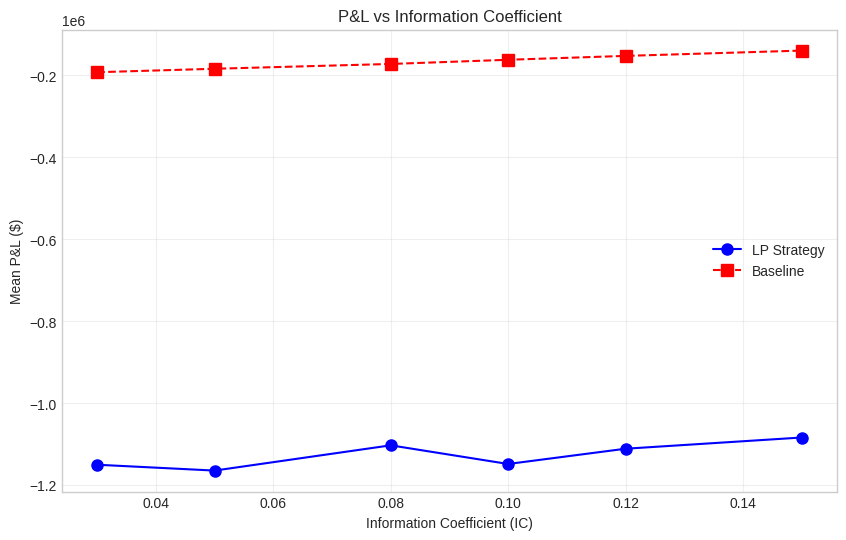

In [13]:
# Plot IC sensitivity
ics, pnls = ic_sweep.get_metric_vs_param('pnl_mean')
_, baseline_pnls = ic_sweep.get_metric_vs_param('baseline_pnl_mean')

plt.figure(figsize=(10, 6))
plt.plot(ics, pnls, 'b-o', label='LP Strategy', markersize=8)
plt.plot(ics, baseline_pnls, 'r--s', label='Baseline', markersize=8)
plt.xlabel('Information Coefficient (IC)')
plt.ylabel('Mean P&L ($)')
plt.title('P&L vs Information Coefficient')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Sweep RFQ rate
rfq_sweep = run_scenario_sweep(
    base_cfg=cfg,
    param_name='rfq_rate_per_day',
    param_values=[5, 10, 15, 20, 30, 40],
    n_paths_per_scenario=20,
    verbose=True,
)


Scenario 1/6: rfq_rate_per_day=5
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-451,786.57
  Std P&L: $456,052.78
  Sharpe: -0.99
  vs Baseline: $-286,269.87
  Outperformance rate: 15.0%

Scenario 2/6: rfq_rate_per_day=10
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-775,086.72
  Std P&L: $464,296.70
  Sharpe: -1.67
  vs Baseline: $-610,271.76
  Outperformance rate: 10.0%

Scenario 3/6: rfq_rate_per_day=15
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-1,148,125.21
  Std P&L: $545,623.59
  Sharpe: -2.10
  vs Baseline: $-986,317.33
  Outperformance rate: 5.0%

Scenario 4/6: rfq_rate_per_day=20
Running path 1/20...
Running path 11/20...
Batch complete: 20 paths
  Mean P&L: $-1,697,010.28
  Std P&L: $660,431.00
  Sharpe: -2.57
  vs Baseline: $-1,529,278.90
  Outperformance rate: 0.0%

Scenario 5/6: rfq_rate_per_day=30
Running path 1/20...
Running path 11/20...
Batch complete: 20 path

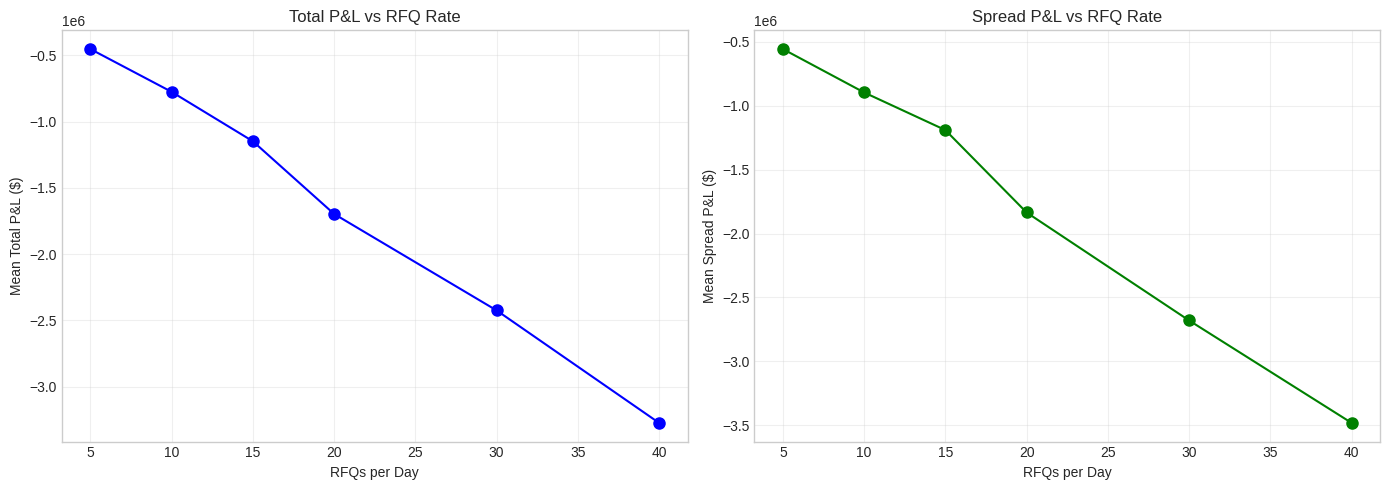

In [15]:
# Plot RFQ rate sensitivity
rates, pnls = rfq_sweep.get_metric_vs_param('pnl_mean')
_, spreads = rfq_sweep.get_metric_vs_param('spread_pnl_mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rates, pnls, 'b-o', markersize=8)
axes[0].set_xlabel('RFQs per Day')
axes[0].set_ylabel('Mean Total P&L ($)')
axes[0].set_title('Total P&L vs RFQ Rate')
axes[0].grid(True, alpha=0.3)

axes[1].plot(rates, spreads, 'g-o', markersize=8)
axes[1].set_xlabel('RFQs per Day')
axes[1].set_ylabel('Mean Spread P&L ($)')
axes[1].set_title('Spread P&L vs RFQ Rate')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Monte Carlo Analysis

Run many paths to get statistical confidence in results.

In [16]:
# Run batch simulation
batch = run_batch(
    cfg=cfg,
    n_paths=100,
    run_baseline_flag=True,
    verbose=True,
)

Running path 1/100...
Running path 11/100...
Running path 21/100...
Running path 31/100...
Running path 41/100...
Running path 51/100...
Running path 61/100...
Running path 71/100...
Running path 81/100...
Running path 91/100...
Batch complete: 100 paths
  Mean P&L: $-1,165,103.74
  Std P&L: $689,807.04
  Sharpe: -1.69
  vs Baseline: $-1,031,704.33
  Outperformance rate: 5.0%


In [17]:
# Display statistics
stats = batch.statistics()

print("\nMONTE CARLO STATISTICS")
print("="*50)
for k, v in stats.items():
    print(f"{k}: {v:,.2f}" if isinstance(v, float) else f"{k}: {v}")


MONTE CARLO STATISTICS
pnl_mean: -1,165,103.74
pnl_std: 689,807.04
pnl_median: -1,006,794.72
pnl_5pct: -2,294,383.42
pnl_95pct: -356,008.18
alpha_pnl_mean: 149,999.61
spread_pnl_mean: -1,315,104.68
fill_rate_mean: 0.55
avg_spread_mean: -24.09
sharpe_of_pnls: -1.69
baseline_pnl_mean: -133,399.41
pnl_vs_baseline: -1,031,704.33
outperformance_rate: 0.05


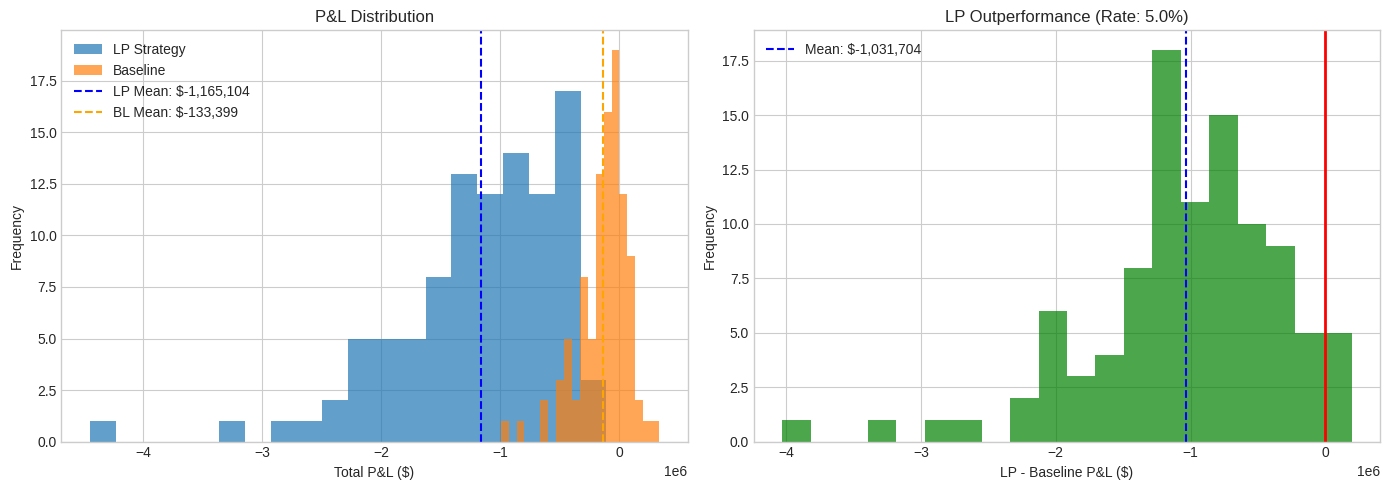

In [18]:
# P&L distribution
pnls = batch.get_pnl_array()
baseline_pnls = np.array([r.total_pnl for r in batch.baseline_results])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(pnls, bins=20, alpha=0.7, label='LP Strategy')
axes[0].hist(baseline_pnls, bins=20, alpha=0.7, label='Baseline')
axes[0].axvline(np.mean(pnls), color='blue', linestyle='--', label=f'LP Mean: ${np.mean(pnls):,.0f}')
axes[0].axvline(np.mean(baseline_pnls), color='orange', linestyle='--', label=f'BL Mean: ${np.mean(baseline_pnls):,.0f}')
axes[0].set_xlabel('Total P&L ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('P&L Distribution')
axes[0].legend()

# Outperformance
diff = pnls - baseline_pnls
axes[1].hist(diff, bins=20, alpha=0.7, color='green')
axes[1].axvline(0, color='red', linestyle='-', linewidth=2)
axes[1].axvline(np.mean(diff), color='blue', linestyle='--', label=f'Mean: ${np.mean(diff):,.0f}')
outperf_rate = (diff > 0).mean()
axes[1].set_xlabel('LP - Baseline P&L ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'LP Outperformance (Rate: {outperf_rate:.1%})')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
# Confidence interval for mean P&L
from scipy import stats as scipy_stats

mean_pnl = np.mean(pnls)
se_pnl = np.std(pnls) / np.sqrt(len(pnls))
ci_95 = scipy_stats.t.interval(0.95, len(pnls)-1, loc=mean_pnl, scale=se_pnl)

print(f"Mean P&L: ${mean_pnl:,.2f}")
print(f"95% CI: [${ci_95[0]:,.2f}, ${ci_95[1]:,.2f}]")
print(f"Sharpe Ratio: {stats['sharpe_of_pnls']:.2f}")

Mean P&L: $-1,165,103.74
95% CI: [$-1,301,976.42, $-1,028,231.05]
Sharpe Ratio: -1.69


---

## Conclusion

The simulator allows us to answer the core question:

**Does spread income exceed alpha lost from slower convergence?**

Key findings:
1. P&L decomposition shows the trade-off between alpha capture and spread earning
2. Win-rate calibration validates the competitor model
3. Sensitivity analysis reveals optimal operating regions
4. Monte Carlo provides statistical confidence

Use the batch runner and scenario sweeps to explore the full parameter space.